**Note: Requires Databricks Serverless GPU A10 Compute with AI v4 Environment.**

**Ensure you have raw dataset loaded in the Volume Catalog before running the notebook**

# Dependency Installation

In [0]:
%pip install --upgrade pip
dbutils.library.restartPython()

%pip install "textacy==0.13.0" fastcoref hf_transfer huggingface_hub ta
dbutils.library.restartPython()

import spacy
spacy.prefer_gpu()
# Download English model
import spacy.cli; spacy.cli.download("en_core_web_sm")
dbutils.library.restartPython()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
DEPRECATION: Using the pkg_resources metadata backend is deprecated. pip 26.3 will enforce this behaviour change. A possible replacement is to use the default importlib.metadata backend, by unsetting the _PIP_USE_IMPORTLIB_METADATA environment variable. Discussion can be found at https://github.com/pypa/pip/issues/13317
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Ins

/databricks/python/lib/python3.12/site-packages/torch/__init__.py:2064: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  _C._initExtension(_manager_path())
DEPRECATION: Using the pkg_resources metadata backend is deprecated. pip 26.3 will enforce this behaviour change. A possible replacement is to use the default importlib.metadata backend, by unsetting the _PIP_USE_IMPORTLIB_METADATA environment variable. Discussion can be found at https://github.com/pypa/pip/issues/13317


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 26.8 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in an interactive Python session, you may need to exit and restart
Python to load all the package's dependencies. You can exit with Ctrl-D (or
Ctrl-Z and Enter on Windows).


# Spark Session

In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

spark = SparkSession.builder.config("spark.sql.session.timeZone", "UTC").appName("FinSentAnalysis").getOrCreate()

# Data Curation

## Financial News Data

In [0]:
WORKSPACE = "paid"
VOLUME = f'/Volumes/{WORKSPACE}/default/ensf612/'

In [0]:
news_df = spark.read.json(f"dbfs:{VOLUME}aapl_news.json").select(*['id', 'created', 'title', 'teaser', 'body'])
news_df.limit(10).display()

id created title teaser body 13077426 Thu, 31 Jan 2019 16:05:36 -0400 Earnings, Volatility, Brexit Are Key Topics Heading Into February February could bring a heaping plate of geopolitical drama to markets around the world, potentially helping to end a brief calm that settled over January. 

 As the month starts, markets were basking in the Federal Reserve’s decision to hold interest rates steady, along with better than expected earnings results from Boeing Co  (NYSE: BA ) and Apple Inc  (NASDAQ: AAPL ). In fact, many Wall Street analysts have indicated they now expect no interest rate increase at all this year after the Fed said it will remain “patient.” So stocks begin February propelled in part by the ongoing earnings season and the Fed’s dovish tone. 

 Still, several question marks hover over the next few weeks. First, the U.S. and China only have about four weeks until their self-imposed early March deadline to get some sort of trade agreement in the books, or we could see tariffs jump. Of course, any more trade tension could likely put the market in a tailspin in both countries and perhaps around the world. As of late January, optimism seeped in around positive developments, but there was no word of an imminent deal. 

 That’s just one reason why volatility—which surged in December as investors fretted about a possible global economic slowdown—could once again become a factor into February. The markets spent January recovering from December’s sell-off, but as a new month begins nothing is certain. Even the government shutdown—which ended with stopgap funding through Feb. 15—could resurface if lawmakers don’t agree on an immigration and border security deal. 

 As of late January, the S&P 500 Index (SPX) was up approximately 7% year to date, the Dow Jones Industrial Average ($DJI) was up about 7.2% and the Nasdaq (COMP) was up 8.2%. At the end of last year, key sectors like info tech, financials, and transports had remained under pressure, signs that investors apparently had doubts about U.S. and global economic growth. But those sectors showed much more buoyancy throughout January. The fact that COMP is leading the major indices might be an early sign of investors starting to embrace more risk, since it’s dominated by tech and biotech names. In addition, the small-cap Russell 2000 (RUT) had the best start to a year since 1987.  

 The market remains headline-driven, meaning the China “news du jour” might drive sentiment on any given day. Certain stocks that sometimes serve as bellwethers reflecting the ups and downs of negotiations— including Boeing and Caterpillar Inc.  (NYSE: CAT )—might be good ones to consider watching for hints about how the market as a whole sees the talks progressing as February rolls along. 

 Brexit, Shutdown Add to Uncertainty  

 However, it’s not just China negotiations echoing around the markets. February is set to begin with Europe and the U.K. still at odds over Brexit. This comes after a vote in January by the U.K. Parliament solidly rejected a compromise agreement put forward by British Prime Minister Theresa May. She survived a no-confidence vote later the same week. Now there’s talk of the U.K. possibly asking the E.U. for an extension of the March 29 exit date. 

 Meanwhile, back in the U.S., a partial government shutdown that found a three-week resolution until Feb. 15 could be followed by more political tension as the investigation of Russia’s alleged interference in the 2016 presidential election seems to be getting close to some kind of conclusion. This isn’t a political column, but any potential fireworks in Washington, D.C., can’t be discounted for their possible impact on the markets. 

 Needless to say, geopolitics looks like it might continue to be a prime contributor to volatility in the stock markets, so the slight easing of market choppiness in the latter half of January shouldn’t necessarily be seen as an extended return to more placid times. The market

### TimeStamp Conversion

In [0]:
news_df = news_df.withColumn('created', regexp_replace('created', r"^[A-Za-z]{3},\s+", "")).withColumn('created', to_timestamp('created', "dd MMM yyyy HH:mm:ss Z")).orderBy('created').withColumnRenamed('created', 'date').withColumn('date', to_date('date'))
news_df.limit(10).display()

id,date,title,teaser,body
5115611,2015-01-02,Hearing Chatter of Overheating in Apple iPhone 6,,
5115509,2015-01-02,Study: 80% Of iPhone Users Not Likely To Buy An Apple Watch Next Year,,"Quartz recently polled 811 smartphone users living in the U.S. asking their intentions to buy Apple Inc.'s (NASDAQ: AAPL) upcoming Apple Watch product. The survey results may be discouraging to Apple investors who expect the product will be met with tremendous demand. According to Quartz, only 2.2 percent iPhone owners surveyed indicated they are ""extremely likely"" to buy an Apple Watch over the next 12 months, while 61.4 percent of those surveyed indicated they are ""not at all likely"" to purchase the product. Of those surveyed who are not iPhone users, 90 percent indicated they are not likely to buy an Apple Watch while less than 1 percent are extremely likely to buy one. Apple's price point may also prove to be an issue. 60.1 percent of respondents stated they are not willing to spend more than $200 on an Apple Watch, despite reports indicating that the most basic Apple Watch will start selling at $350. Eighty-five percent of respondents stated that they wouldn't want to spend ""any money"" on a luxury version of the Apple Watch, while only around 5 percent would be willing to spend more than $2,000 on a luxury version. Finally, 75 percent of respondents indicated that they would need to see an Apple Watch in person at an Apple store or retailer that sells Apple products. Apple recently traded at $109, down 1.25 percent"
5116744,2015-01-03,European Apple Sites Now Show Watch 'Available in 2015; US Site Still Shows 'Coming Early 2015' -9to5Mac,,http://www.apple.com/watch/ http://www.apple.com/uk/watch/
5117542,2015-01-05,Purported Photo Surfaces of 12-inch+ iPad Pro,,http://www.nowhereelse.fr/ipad-pro-air-plus-croquis-103671/
5119658,2015-01-05,'Gartner Says Tablet Sales Continue To Be Slow In 2015',,http://www.gartner.com/newsroom/id/2954317
5119723,2015-01-05,TD Ameritrade's Investment Movement Index Rises In December,,"TD Ameritrade (NYSE: AMTD) released its monthly Investment Movement Index on Monday which tracks the buying and selling habits of the firm's more than six million funded accounts. The index inched slightly higher in December to 5.12, up from 5.11 in November. TD Ameritrade customers bought shares of Apple Inc. (NASDAQ: AAPL), which was the most widely held stock by the firm's clients. Investors also bought shares of GoPro Inc (NASDAQ: GPRO), Twitter Inc (NYSE: TWTR), Kinder Morgan Inc (NYSE: KMI), Southwest Airlines Co (NYSE: LUV) and Transocean LTD (NYSE: RIG). Investors were also acquiring dividend-yielding AT&T Inc. (NYSE: T) and Verizon Communications Inc. (NYSE: VZ) after shares traded at or near yearly lows. Investors took profits from financial firms including Bank of America Corp (NYSE: BAC) and Citigroup (NYSE: C) Technology names like Facebook Inc (NASDAQ: FB), Yahoo! Inc. (NASDAQ: YHOO) and Cisco Systems, Inc. (NASDAQ: CSCO) were net sellers during December."
5120275,2015-01-05,Gartner: No Return For Tablet Sales Boom In 2015,,"Halcyon days for tablet sales won't return any time soon, according to a report Monday from Gartner Inc., which forecast unit sales growth of 8 percent in the current year. ""The collapse of the tablet market in 2014 was alarming,"" said Ranjit Atwal, research director at Gartner, which predicts 233 million tablets in 2015. ""In the last two years, global sales of tablets were growing in double-digits,"" Atwal said. Increasingly, tablet lifetimes are getting extended and software upgrades, especially for Apple Inc. (NASDAQ: AAPL) devices, keep the tablets current. Another factor in slowing sales growth according to Gartner is a lack of innovation in hardware. Gartner expects desk-based and notebook personal computer sales to drop 7.2 percent in the current year to 259 million units, while smartphone sales will increase 3.9 percent to 1.9 billion units. Apple sales will grow 6.4 percent 

### Text Preprocessing

1. Remove HTML Tags
2. Remove New Line, Tab, Carriage Return
3. Replace URL, Emails, Phone Numbers, Emojis, Hashtags, Social User Handles
4. Normalize Bullet Points, Quotation Marks, Multi Line Hyphenation, and White Spaces
5. Remove 'Image' and 'Also Read:..'

In [0]:
# Remove HTML Tags
from bs4 import BeautifulSoup as bs

def parse_html(text: str) -> str:
  return bs(text, 'html.parser').get_text()

# Remove New Line, Tab, Carriage Return
import re
def remove_carriage(text: str) -> str:
  return re.sub(r'\r|\n|\t', ' ', text)

# Remove 'Image' and 'Also Read'
def replace_irrelevant(text: str) -> str:
    return re.sub(r'Image:.*|Also Read: ', '', text)

# Create a Textacy pipeline
import networkx
from textacy.preprocessing import make_pipeline
from textacy.preprocessing.replace import emails, emojis, hashtags, phone_numbers, urls, user_handles
from textacy.preprocessing.normalize import bullet_points, quotation_marks, hyphenated_words, whitespace
text_pipe = make_pipeline(
    parse_html,
    remove_carriage,
    emails,
    emojis,
    hashtags,
    phone_numbers,
    urls,
    user_handles,
    bullet_points,
    quotation_marks,
    hyphenated_words,
    whitespace,
    replace_irrelevant
    )

# Convert into a Spark UDF
def text_preprocessing(text: str) -> str:
  return text_pipe(text)

/databricks/python/lib/python3.12/site-packages/torch/__init__.py:2064: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  _C._initExtension(_manager_path())


In [0]:
pd_df = news_df.toPandas()
pd_df['title'] = pd_df['title'].apply(text_preprocessing)
pd_df['teaser'] = pd_df['teaser'].apply(text_preprocessing)
pd_df['body'] = pd_df['body'].apply(text_preprocessing)
news_df = spark.createDataFrame(pd_df)
news_df.limit(10).display()

/home/spark-db166974-1ab1-4219-bf32-e9/.ipykernel/12695/command-6010254271066829-3156849791:5: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return bs(text, 'html.parser').get_text()
/home/spark-db166974-1ab1-4219-bf32-e9/.ipykernel/12695/command-6010254271066829-3156849791:5: MarkupResemblesLocatorWarning: The input looks more like a URL than markup. You may want to use an HTTP client like requests to get the document behind the URL, and feed that document to Beautiful Soup.
  return bs(text, 'html.parser').get_text()


id,date,title,teaser,body
5115611,2015-01-02,Hearing Chatter of Overheating in Apple iPhone 6,,
5115509,2015-01-02,Study: 80% Of iPhone Users Not Likely To Buy An Apple Watch Next Year,,"Quartz recently polled 811 smartphone users living in the U.S. asking their intentions to buy Apple Inc.'s (NASDAQ: AAPL) upcoming Apple Watch product. The survey results may be discouraging to Apple investors who expect the product will be met with tremendous demand. According to Quartz, only 2.2 percent iPhone owners surveyed indicated they are ""extremely likely"" to buy an Apple Watch over the next 12 months, while 61.4 percent of those surveyed indicated they are ""not at all likely"" to purchase the product. Of those surveyed who are not iPhone users, 90 percent indicated they are not likely to buy an Apple Watch while less than 1 percent are extremely likely to buy one. Apple's price point may also prove to be an issue. 60.1 percent of respondents stated they are not willing to spend more than $200 on an Apple Watch, despite reports indicating that the most basic Apple Watch will start selling at $350. Eighty-five percent of respondents stated that they wouldn't want to spend ""any money"" on a luxury version of the Apple Watch, while only around 5 percent would be willing to spend more than $2,000 on a luxury version. Finally, 75 percent of respondents indicated that they would need to see an Apple Watch in person at an Apple store or retailer that sells Apple products. Apple recently traded at $109, down 1.25 percent"
5116744,2015-01-03,European Apple Sites Now Show Watch 'Available in 2015; US Site Still Shows 'Coming Early 2015' -9to5Mac,,_URL_ _URL_
5117542,2015-01-05,Purported Photo Surfaces of 12-inch+ iPad Pro,,_URL_
5119658,2015-01-05,'Gartner Says Tablet Sales Continue To Be Slow In 2015',,_URL_
5119723,2015-01-05,TD Ameritrade's Investment Movement Index Rises In December,,"TD Ameritrade (NYSE: AMTD) released its monthly Investment Movement Index on Monday which tracks the buying and selling habits of the firm's more than six million funded accounts. The index inched slightly higher in December to 5.12, up from 5.11 in November. TD Ameritrade customers bought shares of Apple Inc. (NASDAQ: AAPL), which was the most widely held stock by the firm's clients. Investors also bought shares of GoPro Inc (NASDAQ: GPRO), Twitter Inc (NYSE: TWTR), Kinder Morgan Inc (NYSE: KMI), Southwest Airlines Co (NYSE: LUV) and Transocean LTD (NYSE: RIG). Investors were also acquiring dividend-yielding AT&T Inc. (NYSE: T) and Verizon Communications Inc. (NYSE: VZ) after shares traded at or near yearly lows. Investors took profits from financial firms including Bank of America Corp (NYSE: BAC) and Citigroup (NYSE: C) Technology names like Facebook Inc (NASDAQ: FB), Yahoo! Inc. (NASDAQ: YHOO) and Cisco Systems, Inc. (NASDAQ: CSCO) were net sellers during December."
5120275,2015-01-05,Gartner: No Return For Tablet Sales Boom In 2015,,"Halcyon days for tablet sales won't return any time soon, according to a report Monday from Gartner Inc., which forecast unit sales growth of 8 percent in the current year. ""The collapse of the tablet market in 2014 was alarming,"" said Ranjit Atwal, research director at Gartner, which predicts 233 million tablets in 2015. ""In the last two years, global sales of tablets were growing in double-digits,"" Atwal said. Increasingly, tablet lifetimes are getting extended and software upgrades, especially for Apple Inc. (NASDAQ: AAPL) devices, keep the tablets current. Another factor in slowing sales growth according to Gartner is a lack of innovation in hardware. Gartner expects desk-based and notebook personal computer sales to drop 7.2 percent in the current year to 259 million units, while smartphone sales will increase 3.9 percent to 1.9 billion units. Apple sales will grow 6.4 percent to 279.4 million units, including iPhones, iPads and PCs. Sales of Microsoft Corporation's (NASDAQ: MSFT) Windows-based devices of all kin

### Coreference Resolution

#### Local Model Cache

In [0]:
from huggingface_hub import snapshot_download
import os

local_tmp = "/tmp/hf_models/fcoref"
os.makedirs(local_tmp, exist_ok=True)

model_tmp = snapshot_download(
    "biu-nlp/f-coref",
    local_dir=local_tmp
)

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/819 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/362M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/393 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

#### Coreference Function

In [0]:
from fastcoref import FCoref
import pandas as pd
import numpy as np

HF_COREF_CACHE_DIR = str(model_tmp)

_coref = None

def get_coref():
    """
    Lazily initialize FCoref once per worker process.
    Called inside the pandas UDF.
    """
    global _coref
    if _coref is None:
        _coref = FCoref(
            model_name_or_path=HF_COREF_CACHE_DIR,
            device="cuda:0",
            enable_progress_bar=False
        )
    return _coref

def get_resolved_text(result) -> str:

    if result is None:
        return None

    """
    Build a "resolved" text by replacing later mentions in each cluster
    with the first mention's surface string.
    """
    text = result.text
    clusters = result.get_clusters(as_strings=False)  # [[(start, end), ...], ...]

    # Collect replacements: (start, end, replacement_text)
    replacements = []

    for cluster in clusters:
        if not cluster:
            continue

        # First span is the canonical mention
        canonical_start, canonical_end = cluster[0]
        canonical_text = text[canonical_start:canonical_end]

        # Replace all *later* mentions with canonical text
        for (start, end) in cluster[1:]:
            replacements.append((start, end, canonical_text))

    # Sort by start index so we can rebuild left→right
    replacements.sort(key=lambda x: x[0])

    # Rebuild the text with replacements applied
    resolved_parts = []
    cur = 0

    for start, end, rep in replacements:
        # add text before this mention
        resolved_parts.append(text[cur:start])
        # add canonical form
        resolved_parts.append(rep)
        # move cursor
        cur = end

    # add the tail of the text
    resolved_parts.append(text[cur:])

    return "".join(resolved_parts)


def coreference_resolution(text: str) -> str:

    if text is None or text == "":
        return None

    return get_resolved_text(get_coref().predict(text))

#### Implementation

In [0]:
new_line = '. '
non_empty_text = lambda x : x.isNotNull() & (x != "")
pd_df = news_df.groupBy('date').agg(
    filter(collect_list('body'), non_empty_text).alias('body'),
    filter(collect_list('title'), non_empty_text).alias('title'),
    filter(collect_list('teaser'), non_empty_text).alias('teaser')
    ).withColumn('body', when(array_size('body') > 0, array_join('body', new_line)).otherwise(None)) \
        .withColumn('title', when(array_size('title') > 0, array_join('title', new_line)).otherwise(None)) \
        .withColumn('teaser', when(array_size('teaser') > 0, array_join('teaser', new_line)).otherwise(None)) \
        .select('date', 'title', 'teaser', 'body').toPandas()
pd_df["body"] = pd_df["body"].apply(coreference_resolution)
pd_df["title"] = pd_df["title"].apply(coreference_resolution)
pd_df["teaser"] = pd_df["teaser"].apply(coreference_resolution)
news_df = spark.createDataFrame(pd_df)
news_df.limit(10).display()

'tuple' object has no attribute 'config'


12/03/2025 04:06:13 - INFO - 	 missing_keys: []
12/03/2025 04:06:13 - INFO - 	 unexpected_keys: []
12/03/2025 04:06:13 - INFO - 	 mismatched_keys: []
12/03/2025 04:06:13 - INFO - 	 error_msgs: []
12/03/2025 04:06:13 - INFO - 	 Model Parameters: 90.5M, Transformer: 82.1M, Coref head: 8.4M
12/03/2025 04:06:13 - INFO - 	 Tokenize 1 inputs...


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

12/03/2025 04:06:13 - INFO - 	 ***** Running Inference on 1 texts *****
12/03/2025 04:06:13 - INFO - 	 Tokenize 1 inputs...


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

12/03/2025 04:47:18 - INFO - 	 ***** Running Inference on 1 texts *****
12/03/2025 04:47:18 - INFO - 	 Tokenize 1 inputs...


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

12/03/2025 04:47:18 - INFO - 	 ***** Running Inference on 1 texts *****


date title teaser body 2016-05-24 Chip Suppliers Cautious Regarding Unit Production for iPhone 7; Suppliers Include Intel, Qualcomm, NXP, Broadcom, Taiwan Semiconductor-DigiTimes. Positive Spotify Earnings; Pressure Grows In Online Music Streaming Market null _URL_. Spotify's revenue has risen to $2.1 billion over the course of 2015, and Spotify's revenue has double in growth from the previous year, Reuters reported. Subscriptions to Spotify's premium service made up 91 percent of the income generation. With risen, Spotify's also saw a large increase in operating expenses as Spotify's launched Spotify'sSpotify's premium service in more countries and invested heavily in product development. Spotify's had a net operating loss of $206.05 million in 2015 versus a $184.38 million in the previous year. Spotify's is pressured by Apple Inc. (NASDAQ: AAPL)'s Apple Music and Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL)'s Google Play Music and YouTube as the market is becoming crowded. Related Link: Pandora Sale? Analyst Says Not So Fast Spotify's launched new content to attract users in the competitive environment. Spotify's now streams videos and podcasts from TED Talks to NPR as well as a cool feature that matches music to the pace of a user's run, according to Reuters. Spotify's also tailored a Discover Weekly feature that custom fits two hours of new music for each individual user. Apple Inc. (NASDAQ: AAPL)'s Apple Music is gaining on Spotify's with 13 million users already in just over a year of launching and currently streams in more than a 100 countries. Competitors for Spotify's also include Pandora, German start up SoundCloud and Jay Z's Tidal. 2016-01-22 Court Documents Show Google Paid Apple $1B to be Default iOS Search Bar Provider in 2014 -AppleInsider. Apple Hires Virtual Reality Researcher Doug Bowman -FT. Suppliers Say Apple Now Placing Orders One Month in Advance Instead of Three, Signaling Likely iPhone Sales Decline -Reuters. Why Did Google Pay Apple $1 Billion?. Fitbit: A Wise Investment Or On Fitbit Way Out?. Did Apple Just Hire A Virtual Reality Expert?. 6 Reasons Apple Has 50% To 85% Upside. Are Apple Suppliers Hinting Of Poor iPhone Demand?. Gene Munster on CNBC Says Apple Should Buy Tesla. The Future Of FordPass. What's Coming For Apple Earnings? Here's What Pacific Crest Thinks. Apple to Launch iPhone 5se in March/April with Curved Edges -9to5Mac. What The Street Expects From Apple Earnings Call Next Tuesday: A Comprehensive View. Goldman Sees Buying Opportunity In Apple Pullback null _URL_. _URL_. _URL_. According to Bloomberg, Google and Google parent company, Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL) handed over $1 billion to Apple Inc. (NASDAQ: AAPL) Bloomberg reported that Apple Inc. (NASDAQ: AAPL) received $1 billion from Google in 2014 as part of a search agreement between the two companies. reported noted that Google gives Apple Inc. (NASDAQ: AAPL) a percentage of the revenue Google generates through Apple Inc. (NASDAQ: AAPL) devices on Google search engines. Bloomberg added that the details were uncovered in a transcript of court proceedings from Oracle Corporation (NYSE: ORCL)'s copyright lawsuit against Google. Related Link: Pope Francis Says Social Media, iPhone And Internet Are A 'Gift Of God' Bloomberg also noted that transcripts from Oracle Corporation (NYSE: ORCL)'sOracle Corporation (NYSE: ORCL)'s copyright lawsuit against Google further revealed that "at one point in time the revenue share was 34 percent" - although it was not clear if 34 percent represents the amount of revenue that Google keeps for Google or is paid out to Apple Inc. (NASDAQ: AAPL). "The specific financial terms of Googlea search agreement between the two companiesApple Inc. (NASDAQ: AAPL) are highly sensitive to the two companiesGoogle and Apple Inc. (NASDAQ: AAPL)," Google said in a January 20 filing, Bloomberg pointed out. "the two companiesApple Inc. (NASDAQ: AAPL) and Google have always treated The specific financial t

### Contextual Sentence Segmentation

#### Segmentation Function

In [0]:
import en_core_web_sm

nlp = en_core_web_sm.load()

APPLE_NAMES = {
    "apple",
    "apple inc.",
    "apple, inc.",
    "apple incorporated",
}

def is_aapl_sentence(span):
    """
    Decide if a sentence is about Apple stock / company.
    Heuristics:
      - contains ticker 'AAPL'
      - or has ORG/PRODUCT entity with Apple name
    """
    text_lower = span.text.lower()

    # Check explicit ticker mention
    if "aapl" in text_lower or "apple" in text_lower:
        return True

    # Check NER entities
    for ent in span.ents:
        if ent.label_ in ("ORG", "PRODUCT"):
            if ent.text.lower() in APPLE_NAMES:
                return True

    return False

@udf("string")
def split_sentences(text):
    if text is None or text == "":
        return None
    
    # Split on sentences
    doc = nlp(text)
    return '|'.join([sent.text.strip() for sent in doc.sents if is_aapl_sentence(sent)])

#### Implementation

In [0]:
news_df = news_df.withColumn('body', split(split_sentences('body'), r'\|')).withColumn('teaser', split(split_sentences('teaser'), r'\|')).withColumn('title', split(split_sentences('title'), r'\|'))

news_df.limit(10).display()

date title teaser body 2016-05-24 List() null List(Spotify's is pressured by Apple Inc. (NASDAQ: AAPL)'s Apple Music and Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL)'s Google Play Music and YouTube as the market is becoming crowded., Apple Inc. (NASDAQ: AAPL)'s Apple Music is gaining on Spotify's with 13 million users already in just over a year of launching and currently streams in more than a 100 countries.) 2016-01-22 List(Court Documents Show Google Paid Apple $1B to be Default iOS Search Bar Provider in 2014 -AppleInsider., Apple Hires Virtual Reality Researcher Doug Bowman -FT., Suppliers Say Apple Now Placing Orders One Month in Advance Instead of Three, Signaling Likely iPhone Sales Decline -Reuters., Why Did Google Pay Apple $1 Billion?., Did Apple Just Hire A Virtual Reality Expert?., 6 Reasons Apple Has 50% To 85% Upside., Are Apple Suppliers Hinting Of Poor iPhone Demand?., Gene Munster on CNBC Says Apple Should Buy Tesla., What's Coming For Apple Earnings?, Apple to Launch iPhone 5se in March/April with Curved Edges -9to5Mac., What The Street Expects From Apple Earnings Call Next Tuesday: A Comprehensive View., Goldman Sees Buying Opportunity In Apple Pullback) null List(According to Bloomberg, Google and Google parent company, Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL) handed over $1 billion to Apple Inc. (NASDAQ: AAPL), Bloomberg reported that Apple Inc. (NASDAQ: AAPL) received $1 billion from Google in 2014 as part of a search agreement between the two companies., reported noted that Google gives Apple Inc. (NASDAQ: AAPL) a percentage of the revenue Google generates through Apple Inc. (NASDAQ: AAPL) devices on Google search engines., Related Link: Pope Francis Says Social Media, iPhone And Internet Are A 'Gift Of God' Bloomberg also noted that transcripts from Oracle Corporation (NYSE: ORCL)'sOracle Corporation (NYSE: ORCL)'s copyright lawsuit against Google further revealed that "at one point in time the revenue share was 34 percent" - although it was not clear if 34 percent represents the amount of revenue that Google keeps for Google or is paid out to Apple Inc. (NASDAQ: AAPL)., "The specific financial terms of Googlea search agreement between the two companiesApple Inc. (NASDAQ: AAPL) are highly sensitive to the two companiesGoogle and Apple Inc. (NASDAQ: AAPL)," Google said in a January 20 filing, Bloomberg pointed out., "the two companiesApple Inc. (NASDAQ: AAPL) and Google have always treated The specific financial terms of Google's agreement with Apple as extremely confidential."., Similar to what has happened to GoPro Inc (NASDAQ: GPRO), many worry that fitness tracking pioneer Fitbit Inc (NYSE: FIT) will become a passing fad, as other wearables like Apple Inc. (NASDAQ: AAPL)'s Apple Watch incorporate similar functionality., According to the Financial Times, Apple Inc. (NASDAQ: AAPL)'s just hired one of the leading minds in virtual reality., the Financial Times reported that Apple Inc. (NASDAQ: AAPL)'s hired one of the leading minds in virtual reality., the Financial Times pointed out that Apple Inc. (NASDAQ: AAPL)'s patents include use of virtual reality in Apple Inc. (NASDAQ: AAPL)'s smartphones., Apple Inc. (NASDAQ: AAPL)'s M&A activity also "point to a growing interest in virtual reality," the Financial Times added., Finally, the Financial Times argued that Apple Inc. (NASDAQ: AAPL)'shired is the "strongest sign yet" of Apple Inc. (NASDAQ: AAPL)'s growing interest in the virtual reality space.., Shares of Apple Inc. (NASDAQ: AAPL)'s are spiking on Friday morning, near $100 per share after Piper Jaffray analyst Gene Munster reiterated that the stock makes a good buy ahead of earnings and said most of the bad news is "priced in.", See Also: Piper Jaffray analyst Gene Munster Cuts iPhone Estimates By 10% Here were Piper Jaffray analyst Gene Munster main points: Apple Inc. (NASDAQ: AAPL)'s current valuation shows most "bad news" is priced into the stock, given the stock similar behavior in 2013., Apple

### Financial News Snapshot

In [0]:
news_df.write.format("delta").mode("overwrite").saveAsTable("aapl_news_curated")

## Financial Price Data

In [0]:
price_df = spark.read.json(f"dbfs:{VOLUME}aapl_price.json").select(col('t').alias('date'), col('o').alias('open'), col('h').alias('high'), col('l').alias('low'), col('c').alias('close'), col('v').alias('volume')) \
    .withColumn('date', to_date(to_timestamp('date', "yyyy-MM-dd'T'HH:mm:ss'Z'"))).orderBy('date')
price_df.limit(10).display()

date,open,high,low,close,volume
2016-01-04,23.16,23.78,23.02,23.78,287741356
2016-01-05,23.87,23.89,23.11,23.18,234762144
2016-01-06,22.69,23.1,22.54,22.73,284319308
2016-01-07,22.27,22.6,21.76,21.77,343985812
2016-01-08,22.24,22.37,21.84,21.88,300265168
2016-01-11,22.34,22.36,21.97,22.24,209502592
2016-01-12,22.69,22.72,22.31,22.56,207483604
2016-01-13,22.64,22.84,21.96,21.98,258901716
2016-01-14,22.11,22.68,21.61,22.46,263175228
2016-01-15,21.71,22.05,21.52,21.92,345021944


### Feature Engineering

#### Technical Indicator Functions

In [0]:
from ta.trend import SMAIndicator
from ta.momentum import RSIIndicator
from ta.volume import OnBalanceVolumeIndicator
import pandas as pd

@pandas_udf('double')
def norm_obv_diff(close: pd.Series, volume: pd.Series) -> pd.Series:
    obv = OnBalanceVolumeIndicator(close=close, volume=volume).on_balance_volume()
    obv_diff = obv.diff()
    obv_sma = SMAIndicator(obv_diff, window=14).sma_indicator()
    return obv_diff/obv_sma

@pandas_udf('double')
def rsi(close: pd.Series) -> pd.Series:
    return RSIIndicator(close=close, window=14).rsi()

@pandas_udf('double')
def norm_close(close: pd.Series) -> pd.Series:
    c_sma = SMAIndicator(close=close, window=14).sma_indicator()
    return close/c_sma

@pandas_udf("double")
def percent_change(series : pd.Series) -> pd.Series:
    return series.shift(-5).pct_change(periods=5)

12/03/2025 04:57:16 - INFO - 	 Received command c on object id p0


#### Implementation

In [0]:
price_df = price_df \
    .withColumn('norm_close', norm_close(col('close'))) \
    .withColumn('norm_obv_diff', norm_obv_diff(col('close'), col('volume'))) \
    .withColumn('rsi', rsi(col('close'))) \
    .withColumn('price_dir', (percent_change(col('close')) > 0).cast('int')) \
    .select('date', 'norm_close', 'norm_obv_diff', 'rsi', 'price_dir')
price_df.limit(10).display()

date,norm_close,norm_obv_diff,rsi,price_dir
2016-01-04,null,null,null,null
2016-01-05,null,null,null,null
2016-01-06,null,null,null,null
2016-01-07,null,null,null,null
2016-01-08,null,null,null,null
2016-01-11,null,null,null,0
2016-01-12,null,null,null,0
2016-01-13,null,null,null,0
2016-01-14,null,null,null,0
2016-01-15,null,null,null,0


### Financial Price Snapshot

In [0]:
price_df.write.format("delta").mode("overwrite").saveAsTable("aapl_price_curated") 

# Sentiment Analysis

## Local Model Cache

In [0]:
from huggingface_hub import snapshot_download
import os

local_tmp = "/tmp/hf_models/finbert"
os.makedirs(local_tmp, exist_ok=True)

# Download HF snapshot into a normal local folder
model_tmp = snapshot_download(
    "ProsusAI/finbert",
    local_dir=local_tmp
)

.gitattributes:   0%|          | 0.00/391 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

flax_model.msgpack:   0%|          | 0.00/438M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

## FinBert Pipeline

In [0]:
HF_CACHE_DIR = model_tmp

from transformers import pipeline
import torch
device = 0 if torch.cuda.is_available() else -1

_classifier = None

def get_finbert():
    global _classifier
    if _classifier is None:
        _classifier = pipeline("text-classification", model=HF_CACHE_DIR,
    tokenizer=HF_CACHE_DIR, top_k=1, device=device)
    return _classifier

12/03/2025 04:57:35 - INFO - 	 Received command c on object id p0


## Sentiment Analysis Function

In [0]:
import builtins
from collections import Counter
import numpy as np

def classify_text(text) -> dict[str, float] | None:

    if (
        text is None 
    or (isinstance(text, str) and text.strip() == "") 
    or (isinstance(text, np.ndarray) and len(text) == 1 and text[0].strip() == "")
    ):
        return None

    clf = get_finbert()  # model created on worker the first time

    if isinstance(text, str):
        text = [text]

    top_labels = []
    top_label_scores = []  # list of (label, score)

    for sent in text:
        try:
            # run FinBERT on the list of sentences
            preds = clf(
                sent
            )
        except:
            return None
    
        for per_sentence in preds:
            # per_sentence is a list like:
            # [{"label": "positive", "score": ...}, {"label": "negative", ...}, ...]
            (label, score) = next((item["label"], float(item["score"])) for item in per_sentence)
            top_labels.append(label)
            top_label_scores.append((label, score))


    all_labels = list(set(top_labels))
    all_labels_dict = [{label : np.mean([score for lbl, score in top_label_scores if lbl == label])} for label in all_labels]
    return {k : v for d in all_labels_dict for k, v in d.items()}

## Implementation

In [0]:
pd_df = news_df.toPandas()
pd_df['sentiment_body'] = pd_df['body'].apply(classify_text)
pd_df['sentiment_title'] = pd_df['title'].apply(classify_text)
pd_df['sentiment_teaser'] = pd_df['teaser'].apply(classify_text)
news_df = spark.createDataFrame(pd_df)
news_df.limit(10).display()

12/03/2025 04:57:35 - INFO - 	 Received command c on object id p0


date title teaser body sentiment_body sentiment_title sentiment_teaser 2016-05-24 List() null List(Spotify's is pressured by Apple Inc. (NASDAQ: AAPL)'s Apple Music and Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL)'s Google Play Music and YouTube as the market is becoming crowded., Apple Inc. (NASDAQ: AAPL)'s Apple Music is gaining on Spotify's with 13 million users already in just over a year of launching and currently streams in more than a 100 countries.) List(0.9618653059005737, null, 0.8117802739143372) null null 2016-01-22 List(Court Documents Show Google Paid Apple $1B to be Default iOS Search Bar Provider in 2014 -AppleInsider., Apple Hires Virtual Reality Researcher Doug Bowman -FT., Suppliers Say Apple Now Placing Orders One Month in Advance Instead of Three, Signaling Likely iPhone Sales Decline -Reuters., Why Did Google Pay Apple $1 Billion?., Did Apple Just Hire A Virtual Reality Expert?., 6 Reasons Apple Has 50% To 85% Upside., Are Apple Suppliers Hinting Of Poor iPhone Demand?., Gene Munster on CNBC Says Apple Should Buy Tesla., What's Coming For Apple Earnings?, Apple to Launch iPhone 5se in March/April with Curved Edges -9to5Mac., What The Street Expects From Apple Earnings Call Next Tuesday: A Comprehensive View., Goldman Sees Buying Opportunity In Apple Pullback) null List(According to Bloomberg, Google and Google parent company, Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL) handed over $1 billion to Apple Inc. (NASDAQ: AAPL), Bloomberg reported that Apple Inc. (NASDAQ: AAPL) received $1 billion from Google in 2014 as part of a search agreement between the two companies., reported noted that Google gives Apple Inc. (NASDAQ: AAPL) a percentage of the revenue Google generates through Apple Inc. (NASDAQ: AAPL) devices on Google search engines., Related Link: Pope Francis Says Social Media, iPhone And Internet Are A 'Gift Of God' Bloomberg also noted that transcripts from Oracle Corporation (NYSE: ORCL)'sOracle Corporation (NYSE: ORCL)'s copyright lawsuit against Google further revealed that "at one point in time the revenue share was 34 percent" - although it was not clear if 34 percent represents the amount of revenue that Google keeps for Google or is paid out to Apple Inc. (NASDAQ: AAPL)., "The specific financial terms of Googlea search agreement between the two companiesApple Inc. (NASDAQ: AAPL) are highly sensitive to the two companiesGoogle and Apple Inc. (NASDAQ: AAPL)," Google said in a January 20 filing, Bloomberg pointed out., "the two companiesApple Inc. (NASDAQ: AAPL) and Google have always treated The specific financial terms of Google's agreement with Apple as extremely confidential."., Similar to what has happened to GoPro Inc (NASDAQ: GPRO), many worry that fitness tracking pioneer Fitbit Inc (NYSE: FIT) will become a passing fad, as other wearables like Apple Inc. (NASDAQ: AAPL)'s Apple Watch incorporate similar functionality., According to the Financial Times, Apple Inc. (NASDAQ: AAPL)'s just hired one of the leading minds in virtual reality., the Financial Times reported that Apple Inc. (NASDAQ: AAPL)'s hired one of the leading minds in virtual reality., the Financial Times pointed out that Apple Inc. (NASDAQ: AAPL)'s patents include use of virtual reality in Apple Inc. (NASDAQ: AAPL)'s smartphones., Apple Inc. (NASDAQ: AAPL)'s M&A activity also "point to a growing interest in virtual reality," the Financial Times added., Finally, the Financial Times argued that Apple Inc. (NASDAQ: AAPL)'shired is the "strongest sign yet" of Apple Inc. (NASDAQ: AAPL)'s growing interest in the virtual reality space.., Shares of Apple Inc. (NASDAQ: AAPL)'s are spiking on Friday morning, near $100 per share after Piper Jaffray analyst Gene Munster reiterated that the stock makes a good buy ahead of earnings and said most of the bad news is "priced in.", See Also: Piper Jaffray analyst Gene Munster Cuts iPhone Estimates By 10% Here were Piper Jaffray analyst Gene Munster main points: Apple Inc. (NASDAQ: AAPL)'s curre

## Sentiment Cleaning

In [0]:
non_empty_score = lambda x : x.score.isNotNull()
news_df = news_df.withColumn('sentiment_title', filter(
       array(
       struct(
              col('sentiment_title.positive').alias('score'), lit('positive').alias('label')
              ),
       struct(
              col('sentiment_title.neutral').alias('score'), lit('neutral').alias('label')
              ),
       struct(
              col('sentiment_title.negative').alias('score'), lit('negative').alias('label')
              )
       ),
       non_empty_score
       )) \
    .withColumn('sentiment_teaser', filter(
       array(
       struct(
              col('sentiment_teaser.positive').alias('score'), lit('positive').alias('label')
              ),
       struct(
              col('sentiment_teaser.neutral').alias('score'), lit('neutral').alias('label')
              ),
       struct(
              col('sentiment_teaser.negative').alias('score'), lit('negative').alias('label')
              )
       ),
       non_empty_score
       )) \
    .withColumn('sentiment_body', filter(
       array(
       struct(
              col('sentiment_body.positive').alias('score'), lit('positive').alias('label')
              ),
       struct(
              col('sentiment_body.neutral').alias('score'), lit('neutral').alias('label')
              ),
       struct(
              col('sentiment_body.negative').alias('score'), lit('negative').alias('label')
              )
       ),
       non_empty_score
       )) \
    .withColumn('sentiment_title', when(size('sentiment_title') > 0, array_max('sentiment_title')).otherwise(lit(None).cast("struct<score:double,label:string>"))) \
       .withColumn('sentiment_teaser', when(size('sentiment_teaser') > 0, array_max('sentiment_teaser')).otherwise(lit(None).cast("struct<score:double,label:string>"))) \
       .withColumn('sentiment_body', when(size('sentiment_body') > 0, array_max('sentiment_body')).otherwise(lit(None).cast("struct<score:double,label:string>"))) \
        .withColumn('sentiment_title_label', when(col('sentiment_title.label') == 'positive', 1).when(col('sentiment_title.label') == 'negative', -1).when(col('sentiment_title.label') == 'neutral', 0).otherwise(None)) \
        .withColumn('sentiment_title_score', col('sentiment_title.score')) \
        .withColumn('sentiment_teaser_label', when(col('sentiment_teaser.label') == 'positive', 1).when(col('sentiment_teaser.label') == 'negative', -1).when(col('sentiment_teaser.label') == 'neutral', 0).otherwise(None)) \
        .withColumn('sentiment_teaser_score', col('sentiment_teaser.score')) \
        .withColumn('sentiment_body_label', when(col('sentiment_body.label') == 'positive', 1).when(col('sentiment_body.label') == 'negative', -1).when(col('sentiment_body.label') == 'neutral', 0).otherwise(None)) \
        .withColumn('sentiment_body_score', col('sentiment_body.score')) \
        .select('date', 'title', 'teaser', 'body', 'sentiment_title_label', 'sentiment_title_score','sentiment_teaser_label', 'sentiment_teaser_score', 'sentiment_body_label', 'sentiment_body_score')
        
news_df.limit(10).display()

date title teaser body sentiment_title_label sentiment_title_score sentiment_teaser_label sentiment_teaser_score sentiment_body_label sentiment_body_score 2016-05-24 List() null List(Spotify's is pressured by Apple Inc. (NASDAQ: AAPL)'s Apple Music and Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL)'s Google Play Music and YouTube as the market is becoming crowded., Apple Inc. (NASDAQ: AAPL)'s Apple Music is gaining on Spotify's with 13 million users already in just over a year of launching and currently streams in more than a 100 countries.) null null null null -1 0.9618653059005737 2016-01-22 List(Court Documents Show Google Paid Apple $1B to be Default iOS Search Bar Provider in 2014 -AppleInsider., Apple Hires Virtual Reality Researcher Doug Bowman -FT., Suppliers Say Apple Now Placing Orders One Month in Advance Instead of Three, Signaling Likely iPhone Sales Decline -Reuters., Why Did Google Pay Apple $1 Billion?., Did Apple Just Hire A Virtual Reality Expert?., 6 Reasons Apple Has 50% To 85% Upside., Are Apple Suppliers Hinting Of Poor iPhone Demand?., Gene Munster on CNBC Says Apple Should Buy Tesla., What's Coming For Apple Earnings?, Apple to Launch iPhone 5se in March/April with Curved Edges -9to5Mac., What The Street Expects From Apple Earnings Call Next Tuesday: A Comprehensive View., Goldman Sees Buying Opportunity In Apple Pullback) null List(According to Bloomberg, Google and Google parent company, Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL) handed over $1 billion to Apple Inc. (NASDAQ: AAPL), Bloomberg reported that Apple Inc. (NASDAQ: AAPL) received $1 billion from Google in 2014 as part of a search agreement between the two companies., reported noted that Google gives Apple Inc. (NASDAQ: AAPL) a percentage of the revenue Google generates through Apple Inc. (NASDAQ: AAPL) devices on Google search engines., Related Link: Pope Francis Says Social Media, iPhone And Internet Are A 'Gift Of God' Bloomberg also noted that transcripts from Oracle Corporation (NYSE: ORCL)'sOracle Corporation (NYSE: ORCL)'s copyright lawsuit against Google further revealed that "at one point in time the revenue share was 34 percent" - although it was not clear if 34 percent represents the amount of revenue that Google keeps for Google or is paid out to Apple Inc. (NASDAQ: AAPL)., "The specific financial terms of Googlea search agreement between the two companiesApple Inc. (NASDAQ: AAPL) are highly sensitive to the two companiesGoogle and Apple Inc. (NASDAQ: AAPL)," Google said in a January 20 filing, Bloomberg pointed out., "the two companiesApple Inc. (NASDAQ: AAPL) and Google have always treated The specific financial terms of Google's agreement with Apple as extremely confidential."., Similar to what has happened to GoPro Inc (NASDAQ: GPRO), many worry that fitness tracking pioneer Fitbit Inc (NYSE: FIT) will become a passing fad, as other wearables like Apple Inc. (NASDAQ: AAPL)'s Apple Watch incorporate similar functionality., According to the Financial Times, Apple Inc. (NASDAQ: AAPL)'s just hired one of the leading minds in virtual reality., the Financial Times reported that Apple Inc. (NASDAQ: AAPL)'s hired one of the leading minds in virtual reality., the Financial Times pointed out that Apple Inc. (NASDAQ: AAPL)'s patents include use of virtual reality in Apple Inc. (NASDAQ: AAPL)'s smartphones., Apple Inc. (NASDAQ: AAPL)'s M&A activity also "point to a growing interest in virtual reality," the Financial Times added., Finally, the Financial Times argued that Apple Inc. (NASDAQ: AAPL)'shired is the "strongest sign yet" of Apple Inc. (NASDAQ: AAPL)'s growing interest in the virtual reality space.., Shares of Apple Inc. (NASDAQ: AAPL)'s are spiking on Friday morning, near $100 per share after Piper Jaffray analyst Gene Munster reiterated that the stock makes a good buy ahead of earnings and said most of the bad news is "priced in.", See Also: Piper Jaffray analyst Gene Munster Cuts iPhone Estimates By 10% Here were Piper Jaffray an

## Snapshot

In [0]:
news_df.write \
  .format("delta") \
  .mode("overwrite") \
  .saveAsTable("aapl_news_sentiment")

# ML DataSet

## Price & News Data Join

In [0]:
df = price_df.join(news_df, on='date', how='left').select('date', 'norm_close', 'norm_obv_diff', 'rsi', 'sentiment_title_label', 'sentiment_title_score', 'sentiment_body_label', 'sentiment_body_score', 'price_dir').dropna().orderBy('date')
df.limit(10).display()

date,norm_close,norm_obv_diff,rsi,sentiment_title_label,sentiment_title_score,sentiment_body_label,sentiment_body_score,price_dir
2016-01-25,1.0087660148347943,5.585074066424227,45.501327166737994,-1,0.9222015738487244,-1,0.9000985432754863,0
2016-01-26,1.0166012483109192,-164.2736182634751,47.341453811114604,1,0.9387950897216797,-1,0.8852955141793126,0
2016-01-27,0.9545557460296923,26.611334972475124,33.415219335921535,1,0.911894420782725,-1,0.8613922156271387,1
2016-01-28,0.9630301655704242,11.1969648527545,35.47311102650707,0,0.8852976262569427,-1,0.9185553590456644,1
2016-01-29,0.9963073335060896,14.671848543245746,44.574043296340314,0,0.8513638496398925,-1,0.9410427138209343,0
2016-02-01,0.9883207889955878,22.993208452922932,42.732118730796415,0,0.816903680562973,1,0.8717497661709785,0
2016-02-02,0.9722475570032574,4.677671794247363,39.08754862095032,1,0.9468815326690674,1,0.8910778363545736,1
2016-02-03,0.9921762941713392,-148.18862143201073,43.99753537334942,1,0.9519302248954773,1,0.9289532601833344,0
2016-02-04,1.0021553131735352,-31.12162665539864,46.00628295526967,1,0.760764459768931,1,0.8790052980184555,0
2016-02-05,0.9770637699178745,-42.16625429115523,40.83588058890412,0,0.7213319540023804,-1,0.9189659357070923,0


## Snapshot

In [0]:
df.write \
  .format("delta") \
  .mode("overwrite") \
  .saveAsTable("aapl_ml_data")

12/03/2025 05:17:57 - INFO - 	 Received command c on object id p0


# Machine Learning

## Train Test Split

In [0]:
pd_df = df.orderBy('date').toPandas().set_index('date')

total = pd_df.index.size
split_idx = total - int(total * 0.2)

pd_df_wo_sent = pd_df[['norm_close', 'norm_obv_diff', 'rsi', 'price_dir']]

pd_df_w_sent = pd_df[['norm_close', 'norm_obv_diff', 'rsi', 'sentiment_title_label', 'sentiment_title_score', 'sentiment_body_label', 'sentiment_body_score', 'price_dir']]

X_wo_sent = pd_df_wo_sent.drop('price_dir', axis=1)
y_wo_sent = pd_df_wo_sent['price_dir']

X_w_sent = pd_df_w_sent.drop('price_dir', axis=1)
y_w_sent = pd_df_w_sent['price_dir']


X_train_wo_sent, X_test_wo_sent = X_wo_sent.iloc[:split_idx], X_wo_sent.iloc[split_idx:]
y_train_wo_sent, y_test_wo_sent = y_wo_sent.iloc[:split_idx], y_wo_sent.iloc[split_idx:]

X_train_w_sent, X_test_w_sent = X_w_sent.iloc[:split_idx], X_w_sent.iloc[split_idx:]
y_train_w_sent, y_test_w_sent = y_w_sent.iloc[:split_idx], y_w_sent.iloc[split_idx:]


12/03/2025 05:18:00 - INFO - 	 Received command c on object id p0


## Model Initialization

In [0]:
import xgboost as xgb

clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",     # GPU trainer
    predictor="gpu_predictor",  # GPU inference,
    device="cuda",    
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
)

## Fit without Sentiment Analysis

In [0]:
clf.fit(X_train_wo_sent, y_train_wo_sent)

train_pred_wo_sent = clf.predict(X_train_wo_sent)

test_pred_wo_sent = clf.predict(X_test_wo_sent)

12/03/2025 05:18:02 - INFO - 	 Received command c on object id p0
/local_disk0/.ephemeral_nfs/envs/pythonEnv-db166974-1ab1-4219-bf32-e99bbf0da08d/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [05:18:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-db166974-1ab1-4219-bf32-e99bbf0da08d/lib/python3.12/site-packages/xgboost/core.py:729: UserWarning: [05:18:04] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


## Fit with Sentiment Analysis

In [0]:
clf.fit(X_train_w_sent, y_train_w_sent)

train_pred_w_sent = clf.predict(X_train_w_sent)

test_pred_w_sent = clf.predict(X_test_w_sent)


12/03/2025 05:18:04 - INFO - 	 Received command c on object id p0
/local_disk0/.ephemeral_nfs/envs/pythonEnv-db166974-1ab1-4219-bf32-e99bbf0da08d/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [05:18:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Metrics

In [0]:
from sklearn.metrics import accuracy_score

print("XGBoost without Sentiment Analysis")
print("Training Accuracy:", accuracy_score(y_train_wo_sent, train_pred_wo_sent) * 100)
print("Testing Accuracy:", accuracy_score(y_test_wo_sent, test_pred_wo_sent) * 100)
print("")
print("XGBoost with Sentiment Analysis")
print("Training Accuracy:", accuracy_score(y_train_w_sent, train_pred_w_sent) * 100)
print("Testing Accuracy:", accuracy_score(y_test_w_sent, test_pred_w_sent) * 100)

12/03/2025 05:18:04 - INFO - 	 Received command c on object id p0


XGBoost without Sentiment Analysis
Training Accuracy: 86.20689655172413
Testing Accuracy: 52.95566502463054

XGBoost with Sentiment Analysis
Training Accuracy: 94.08866995073892
Testing Accuracy: 52.463054187192114


## Confusion Matrix

In [0]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

12/03/2025 05:18:05 - INFO - 	 Received command c on object id p0
12/03/2025 05:18:07 - INFO - 	 generated new fontManager


### Without Sentiment Analysis

In [0]:
y_predict_wo_sent = pd.DataFrame(np.concat([train_pred_wo_sent, test_pred_wo_sent], axis=0), columns=['price_dir'], index=pd_df.index)
y_true_wo_sent = pd.concat([y_train_wo_sent, y_test_wo_sent], axis=0)
cm_wo_sent = confusion_matrix(y_true_wo_sent, y_predict_wo_sent)

12/03/2025 05:18:08 - INFO - 	 Received command c on object id p0


### With Sentiment Analysis

In [0]:
import numpy as np
y_predict_w_sent = pd.DataFrame(np.concat([train_pred_w_sent, test_pred_w_sent], axis=0), columns=['price_dir'], index=pd_df.index)
y_true_w_sent = pd.concat([y_train_w_sent, y_test_w_sent], axis=0)
cm_w_sent = confusion_matrix(y_true_w_sent, y_predict_w_sent)

### Plots

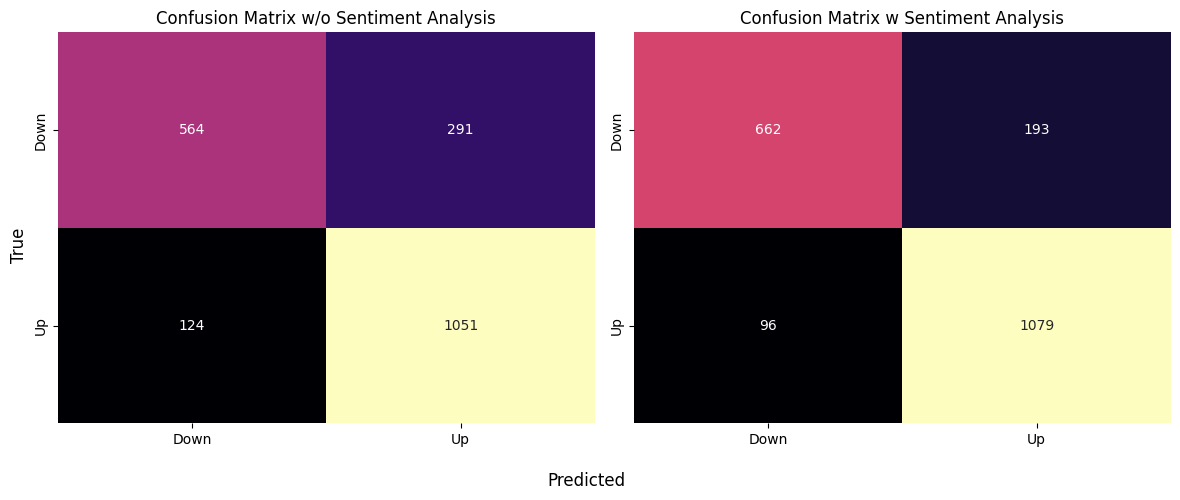

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_wo_sent, ax=axes[0], cmap="magma", annot=True, fmt="d", cbar=False, xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
axes[0].set_title("Confusion Matrix w/o Sentiment Analysis")

sns.heatmap(cm_w_sent, ax=axes[1], cmap="magma", annot=True, fmt="d", cbar=False, xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
axes[1].set_title("Confusion Matrix w Sentiment Analysis")

fig.supxlabel("Predicted")
fig.supylabel("True")

plt.tight_layout()
plt.show()


## Feature Correlation Matrix

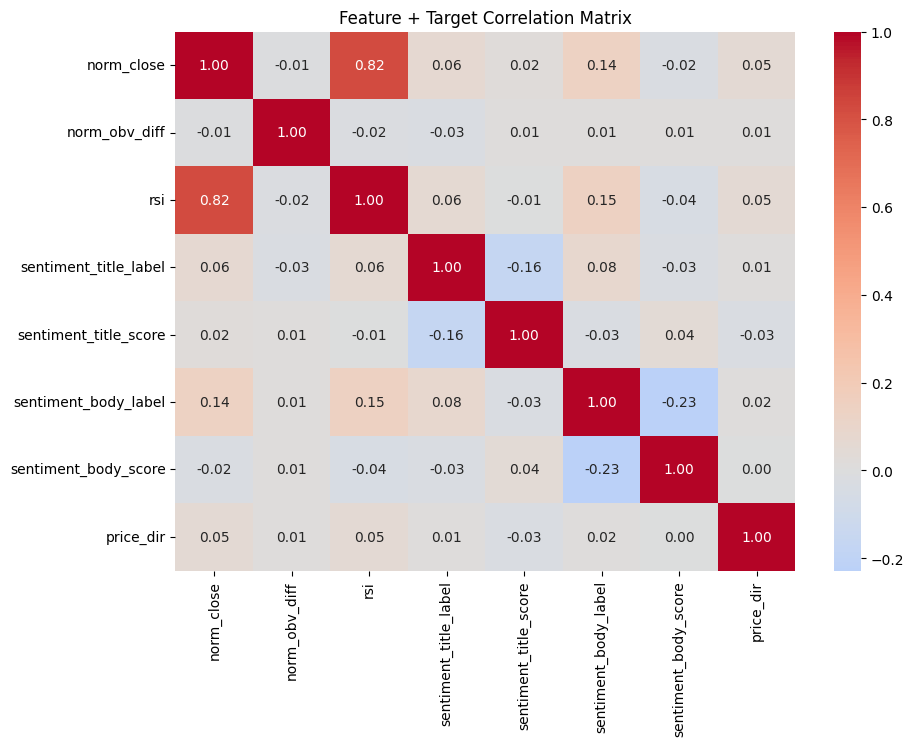

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr = pd_df.corr()

plt.figure(figsize=(10, 7))
ax = sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
ax.set_title("Feature + Target Correlation Matrix")
plt.show()

# Resources

1. [https://arxiv.org/pdf/2306.02136](https://arxiv.org/pdf/2306.02136)
2. [https://medium.com/prosus-ai-tech-blog/finbert-financial-sentiment-analysis-with-bert-b277a3607101](https://medium.com/prosus-ai-tech-blog/finbert-financial-sentiment-analysis-with-bert-b277a3607101)